# Homework 2 – Regression and Classification Error Analysis

## NBA Games Dataset

This notebook analyzes regression and classification model errors using historical NBA game data.

The analysis uses `games.csv` as the main dataset and enriches it with pre-game team information from `ranking.csv`.

All model evaluation will be performed using k-fold cross-validation, as required by the assignment.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
games = pd.read_csv("data/games.csv")
ranking = pd.read_csv("data/ranking.csv")

## Data Preparation for Modeling

The `games.csv` file is used as the main table, with one NBA game per observation.

To avoid target leakage, game outcome statistics are not used as predictors. Instead, pre-game team information is obtained from `ranking.csv` using the standings from the day before each game.

For the regression task, the target variable is `PTS_home`, representing the number of points scored by the home team.

The initial feature set contains simple information available before the game:
- Season
- Home team winning percentage
- Away team winning percentage
- Number of games already played by the home team
- Number of games already played by the away team

In [3]:
games["GAME_DATE_EST"] = pd.to_datetime(games["GAME_DATE_EST"])
ranking["STANDINGSDATE"] = pd.to_datetime(ranking["STANDINGSDATE"])

ranking_clean = ranking.drop_duplicates(
    subset=["TEAM_ID", "STANDINGSDATE"]
).copy()

In [4]:
model_data = games[
    [
        "GAME_DATE_EST",
        "GAME_ID",
        "HOME_TEAM_ID",
        "VISITOR_TEAM_ID",
        "SEASON",
        "PTS_home",
        "HOME_TEAM_WINS"
    ]
].copy()

model_data["RANK_DATE"] = (
    model_data["GAME_DATE_EST"] - pd.Timedelta(days=1)
)

In [5]:
home_ranking = ranking_clean[
    ["TEAM_ID", "STANDINGSDATE", "G", "W_PCT"]
].copy()

home_ranking = home_ranking.rename(
    columns={
        "TEAM_ID": "HOME_TEAM_ID",
        "STANDINGSDATE": "RANK_DATE",
        "G": "HOME_G",
        "W_PCT": "HOME_W_PCT"
    }
)

In [6]:
away_ranking = ranking_clean[
    ["TEAM_ID", "STANDINGSDATE", "G", "W_PCT"]
].copy()

away_ranking = away_ranking.rename(
    columns={
        "TEAM_ID": "VISITOR_TEAM_ID",
        "STANDINGSDATE": "RANK_DATE",
        "G": "AWAY_G",
        "W_PCT": "AWAY_W_PCT"
    }
)

In [7]:
model_data = model_data.merge(
    home_ranking,
    on=["HOME_TEAM_ID", "RANK_DATE"],
    how="left"
)

model_data = model_data.merge(
    away_ranking,
    on=["VISITOR_TEAM_ID", "RANK_DATE"],
    how="left"
)

In [8]:
model_data = model_data.dropna(
    subset=[
        "PTS_home",
        "HOME_G",
        "HOME_W_PCT",
        "AWAY_G",
        "AWAY_W_PCT"
    ]
).copy()

Rows with missing target values or missing pre-game ranking information were removed because they cannot be used directly by the selected regression models.

In [9]:
regression_features = [
    "SEASON",
    "HOME_W_PCT",
    "AWAY_W_PCT",
    "HOME_G",
    "AWAY_G"
]

X_reg = model_data[regression_features]
y_reg = model_data["PTS_home"]

In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_predict

### Cross-Validation Strategy

A 5-fold cross-validation strategy is used throughout the regression analysis.

The dataset contains more than 26,000 games, so each fold still contains several thousand observations. Using five folds provides a practical balance between computational cost and the bias-variance trade-off while producing predictions for every observation from a model that was not trained on that observation.

Because the dataset spans multiple seasons, random k-fold cross-validation does not reproduce a strictly chronological forecasting setting. It is used here to follow the assignment requirement and to obtain consistent out-of-fold error estimates across the dataset.

# 1. Regression Error Analysis

## 1.1 Residual Analysis

A Linear Regression model is used as the initial baseline model for residual analysis.

Residuals are defined as:

$$
\text{Residual} = y - \hat{y}
$$

Out-of-fold predictions are generated using 5-fold cross-validation so that each residual is calculated from a prediction made on an observation that was not used to train the corresponding model.

In [11]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

linear_model = LinearRegression()

y_pred_reg = cross_val_predict(
    linear_model,
    X_reg,
    y_reg,
    cv=cv
)

residuals = y_reg.to_numpy() - y_pred_reg

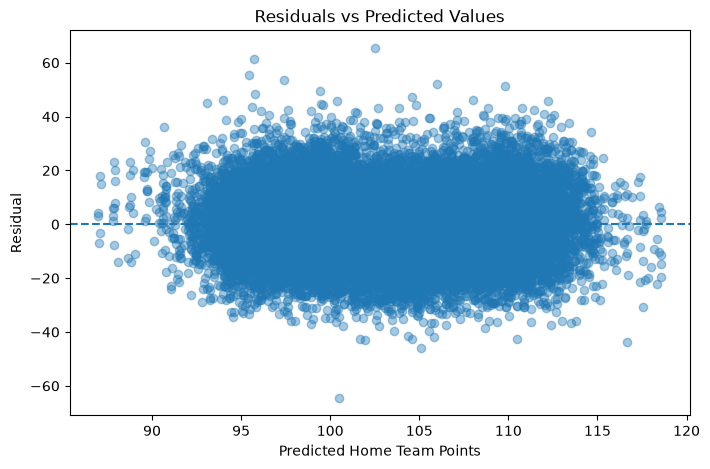

In [12]:
plt.figure(figsize=(8, 5))

plt.scatter(
    y_pred_reg,
    residuals,
    alpha=0.4
)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted Home Team Points")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted Values")

plt.show()

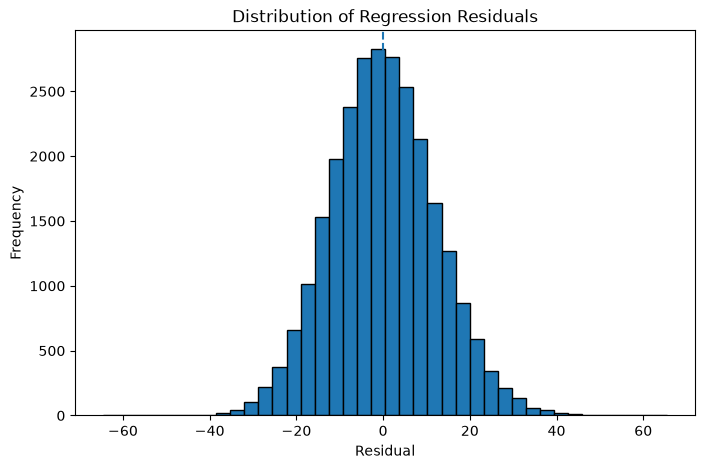

In [13]:
plt.figure(figsize=(8, 5))

plt.hist(
    residuals,
    bins=40,
    edgecolor="black"
)

plt.axvline(0, linestyle="--")

plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Regression Residuals")

plt.show()

### Interpretation

The residuals are centered very close to zero. The mean residual is approximately zero, indicating that the Linear Regression model does not show a strong overall tendency to systematically overpredict or underpredict home-team points.

The residual plot does not show a clear systematic curve or trend across the predicted values. Most residuals are distributed on both sides of zero throughout the main prediction range.

There is no strong visual evidence of heteroscedasticity. The vertical spread of the residuals remains relatively similar across most predicted values. The smaller spread at the extreme predicted values is also influenced by the smaller number of observations in these regions.

The residual distribution is approximately symmetric and centered around zero. Most errors are moderate, although a small number of observations have very large positive or negative residuals.

No specific predicted-value region clearly contains consistently larger errors. Large errors appear across different predicted values. Feature-based error patterns and possible subpopulations will be examined more directly in Section 1.2.

## 1.2 Error as a Function of Features

To examine whether model errors depend on specific input features, residuals and absolute errors are compared with the pre-game variables used by the regression model.

The analysis includes:
- Home team winning percentage
- Away team winning percentage
- Number of games played by the home team
- Number of games played by the away team
- Season

These features represent team strength, stage of the season, and temporal variation.

In [14]:
error_analysis = X_reg.copy()

error_analysis["Residual"] = residuals
error_analysis["Absolute_Error"] = np.abs(residuals)

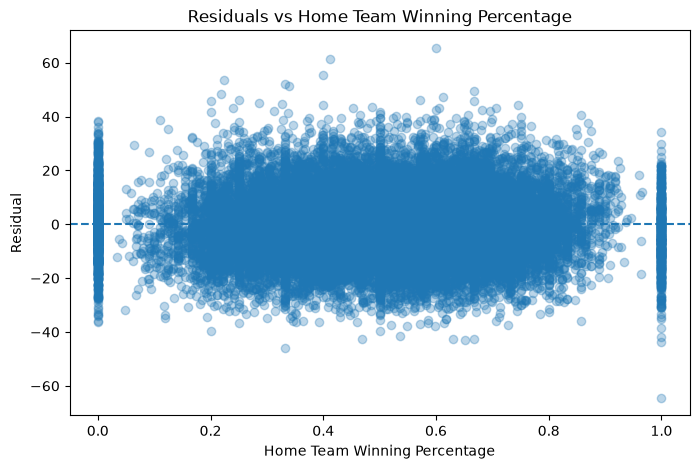

In [15]:
plt.figure(figsize=(8, 5))

plt.scatter(
    error_analysis["HOME_W_PCT"],
    error_analysis["Residual"],
    alpha=0.3
)

plt.axhline(0, linestyle="--")

plt.xlabel("Home Team Winning Percentage")
plt.ylabel("Residual")
plt.title("Residuals vs Home Team Winning Percentage")

plt.show()

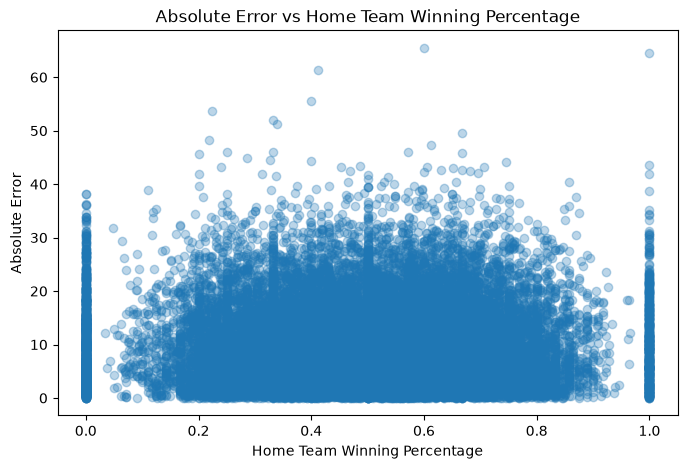

In [16]:
plt.figure(figsize=(8, 5))

plt.scatter(
    error_analysis["HOME_W_PCT"],
    error_analysis["Absolute_Error"],
    alpha=0.3
)

plt.xlabel("Home Team Winning Percentage")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs Home Team Winning Percentage")

plt.show()

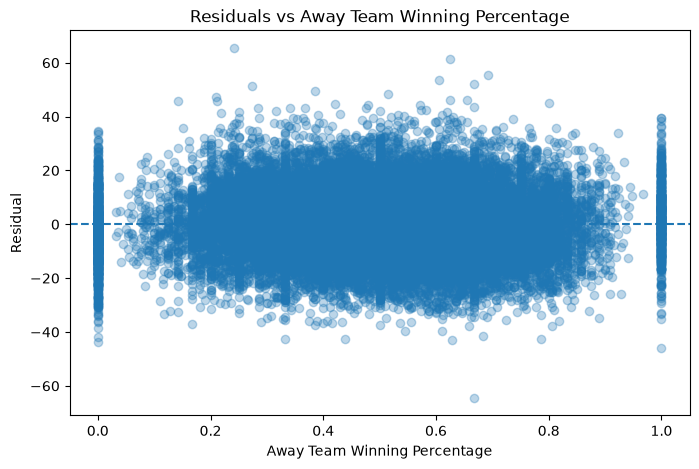

In [17]:
plt.figure(figsize=(8, 5))

plt.scatter(
    error_analysis["AWAY_W_PCT"],
    error_analysis["Residual"],
    alpha=0.3
)

plt.axhline(0, linestyle="--")

plt.xlabel("Away Team Winning Percentage")
plt.ylabel("Residual")
plt.title("Residuals vs Away Team Winning Percentage")

plt.show()

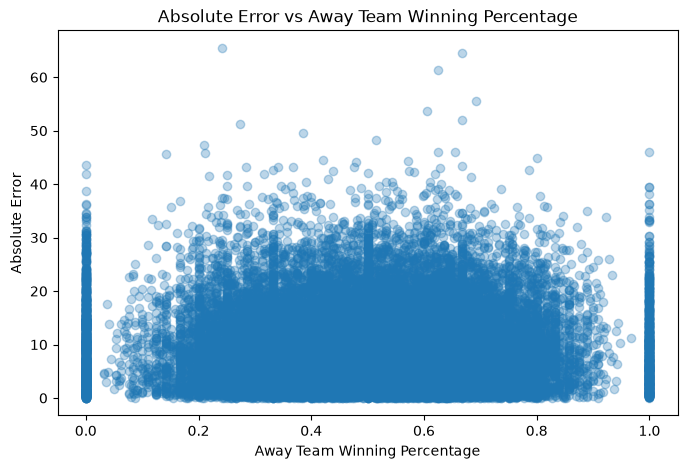

In [18]:
plt.figure(figsize=(8, 5))

plt.scatter(
    error_analysis["AWAY_W_PCT"],
    error_analysis["Absolute_Error"],
    alpha=0.3
)

plt.xlabel("Away Team Winning Percentage")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs Away Team Winning Percentage")

plt.show()

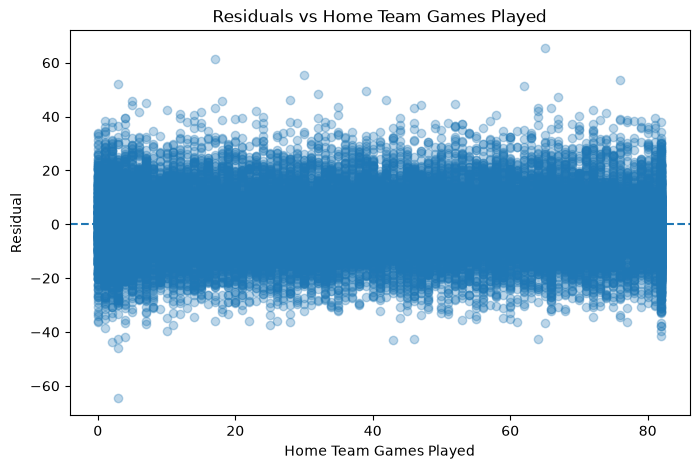

In [19]:
plt.figure(figsize=(8, 5))

plt.scatter(
    error_analysis["HOME_G"],
    error_analysis["Residual"],
    alpha=0.3
)

plt.axhline(0, linestyle="--")

plt.xlabel("Home Team Games Played")
plt.ylabel("Residual")
plt.title("Residuals vs Home Team Games Played")

plt.show()

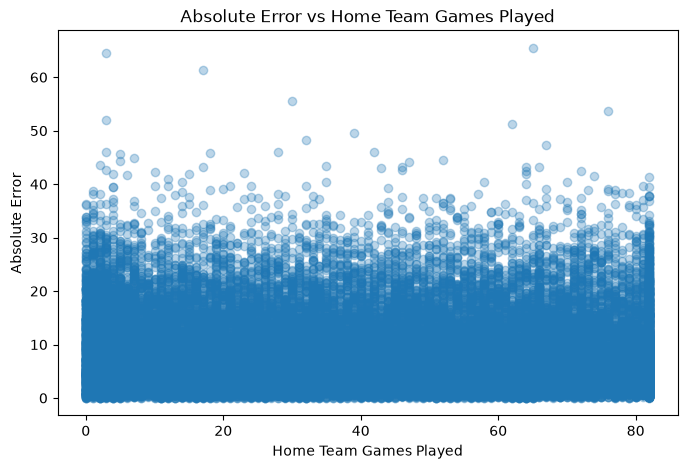

In [20]:
plt.figure(figsize=(8, 5))

plt.scatter(
    error_analysis["HOME_G"],
    error_analysis["Absolute_Error"],
    alpha=0.3
)

plt.xlabel("Home Team Games Played")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs Home Team Games Played")

plt.show()

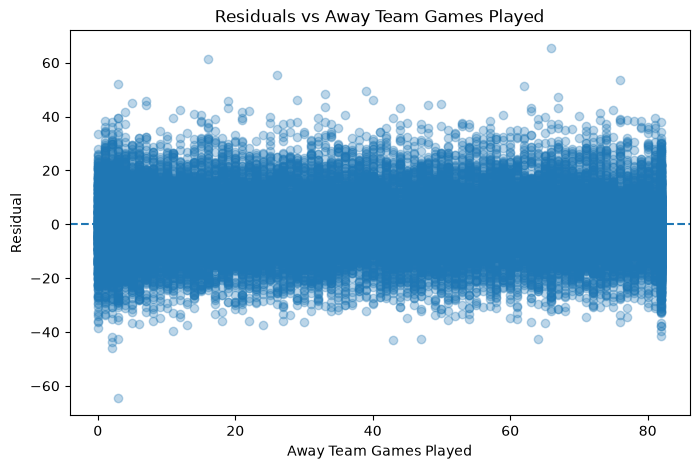

In [21]:
plt.figure(figsize=(8, 5))

plt.scatter(
    error_analysis["AWAY_G"],
    error_analysis["Residual"],
    alpha=0.3
)

plt.axhline(0, linestyle="--")

plt.xlabel("Away Team Games Played")
plt.ylabel("Residual")
plt.title("Residuals vs Away Team Games Played")

plt.show()

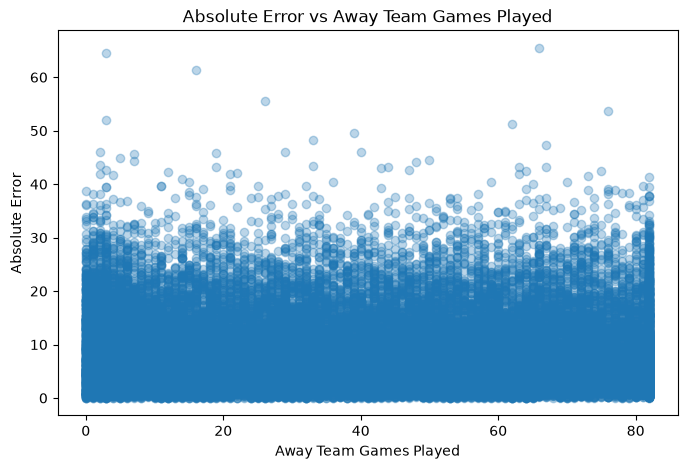

In [22]:
plt.figure(figsize=(8, 5))

plt.scatter(
    error_analysis["AWAY_G"],
    error_analysis["Absolute_Error"],
    alpha=0.3
)

plt.xlabel("Away Team Games Played")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs Away Team Games Played")

plt.show()

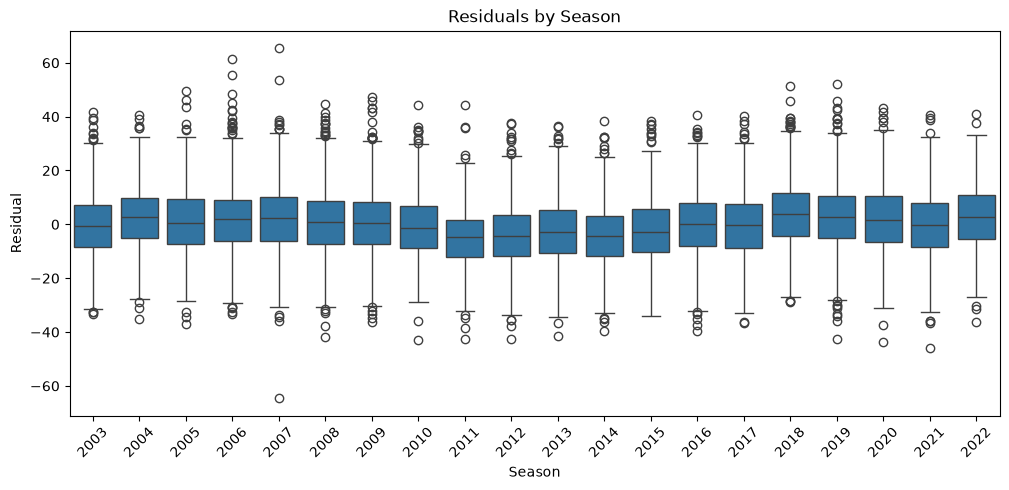

In [23]:
plt.figure(figsize=(12, 5))

sns.boxplot(
    data=error_analysis,
    x="SEASON",
    y="Residual"
)

plt.xticks(rotation=45)

plt.xlabel("Season")
plt.ylabel("Residual")
plt.title("Residuals by Season")

plt.show()

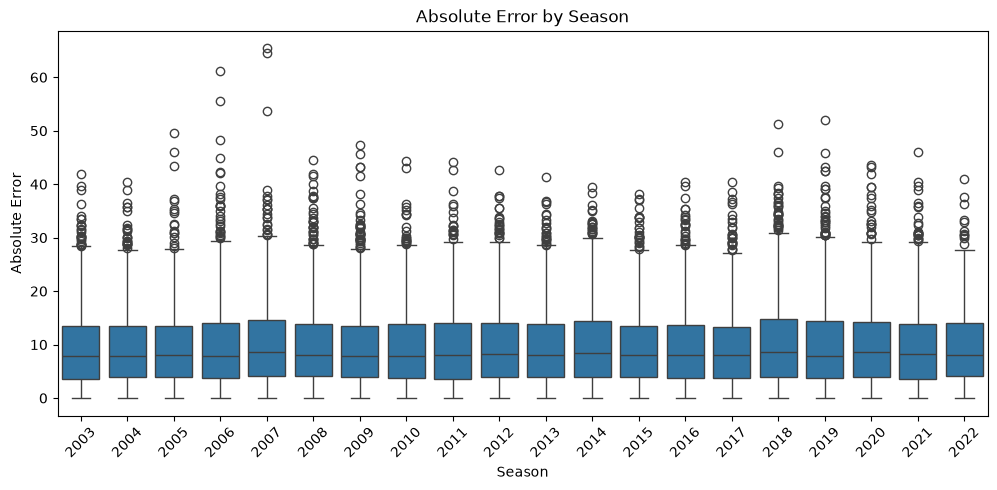

In [24]:
plt.figure(figsize=(12, 5))

sns.boxplot(
    data=error_analysis,
    x="SEASON",
    y="Absolute_Error"
)

plt.xticks(rotation=45)

plt.xlabel("Season")
plt.ylabel("Absolute Error")
plt.title("Absolute Error by Season")

plt.show()

### Interpretation

The residuals remain distributed around zero across most values of the analyzed features.

For both home and away team winning percentages, no clear nonlinear pattern or systematic directional bias is visible. Large absolute errors occur across a wide range of winning percentages rather than being concentrated only among very weak or very strong teams.

Noticeable vertical concentrations occur at winning percentages of 0 and 1. These values are common early in a season, when teams have played only a small number of games. Although these observations form distinct subpopulations, they do not show a clearly larger error distribution than the rest of the data.

The number of games already played by the home and away teams also does not show a strong relationship with either residual direction or absolute error size. Errors remain broadly distributed throughout the season, suggesting that model performance does not consistently improve or deteriorate as more games are played.

The season-based residual analysis shows some variation in the center and spread of the residuals across years. Some seasons exhibit slightly more positive or negative residuals, indicating small season-specific differences in model bias. However, these differences are moderate rather than extreme.

The absolute-error distributions are also relatively similar across seasons, although some seasons contain more extreme observations.

Overall, the selected features do not reveal a single strong feature-dependent failure region. The model appears to make moderate errors across most of the feature space, while a smaller number of observations produce unusually large errors.

## 1.3 Analysis of Extreme Errors

To examine the most severe regression failures, the observations with the largest 5% of absolute prediction errors are identified and analyzed separately.

The goal is to determine whether these errors are mainly associated with data quality issues, model limitations, or rare and exceptional game outcomes.

In [25]:
extreme_error_data = model_data[
    [
        "GAME_DATE_EST",
        "GAME_ID",
        "HOME_TEAM_ID",
        "VISITOR_TEAM_ID",
        "SEASON",
        "PTS_home",
        "HOME_W_PCT",
        "AWAY_W_PCT",
        "HOME_G",
        "AWAY_G"
    ]
].copy()

extreme_error_data["Predicted_PTS_home"] = y_pred_reg
extreme_error_data["Residual"] = residuals
extreme_error_data["Absolute_Error"] = np.abs(residuals)

In [26]:
error_threshold = extreme_error_data["Absolute_Error"].quantile(0.95)

extreme_errors = extreme_error_data[
    extreme_error_data["Absolute_Error"] >= error_threshold
].copy()

extreme_errors = extreme_errors.sort_values(
    "Absolute_Error",
    ascending=False
)

In [27]:
print("95th percentile threshold:", round(error_threshold, 2))
print("Number of extreme-error observations:", len(extreme_errors))

extreme_errors.head(10)

95th percentile threshold: 23.8
Number of extreme-error observations: 1328


,GAME_DATE_EST,GAME_ID,HOME_TEAM_ID,VISITOR_TEAM_ID,SEASON,PTS_home,HOME_W_PCT,AWAY_W_PCT,HOME_G,AWAY_G,Predicted_PTS_home,Residual,Absolute_Error
12610,2008-03-16,20700989,1610612743,1610612760,2007,168.0,0.600,0.242,65,66,102.531560,65.468440,65.468440
13632,2007-10-19,10700072,1610612738,1610612751,2007,36.0,1.000,0.667,3,3,100.513388,-64.513388,64.513388
14727,2006-12-07,20600271,1610612751,1610612756,2006,157.0,0.412,0.625,17,16,95.740331,61.259669,61.259669
14581,2006-12-27,20600420,1610612752,1610612765,2006,151.0,0.400,0.692,30,26,95.456444,55.543556,55.543556
12445,2008-04-06,20701151,1610612760,1610612743,2007,151.0,0.224,0.605,76,76,97.379416,53.620584,53.620584
19528,2019-10-30,21900061,1610612764,1610612745,2019,158.0,0.333,0.667,3,3,105.993728,52.006272,52.006272
20030,2019-03-01,21800928,1610612737,1610612741,2018,161.0,0.339,0.274,62,62,109.806462,51.193538,51.193538
15842,2006-01-22,20500589,1610612756,1610612760,2005,149.0,0.667,0.385,39,39,99.424769,49.575231,49.575231
14531,2007-01-03,20600471,1610612763,1610612744,2006,144.0,0.219,0.515,32,33,95.766792,48.233208,48.233208
9745,2010-03-16,20901003,1610612756,1610612750,2009,152.0,0.612,0.209,67,67,104.593507,47.406493,47.406493


### Individual Extreme Cases

The largest errors include unusually high and unusually low scoring games.

For example, the largest positive residual occurred in a game where the home team scored 168 points while the model predicted approximately 103 points. This resulted in an error of more than 65 points.

In the opposite direction, another game had only 36 home-team points while the model predicted approximately 101 points, producing an error of about 65 points.

Several other large errors are also associated with unusually high home-team scores, such as 151, 157, 158, and 161 points.

These examples suggest that the Linear Regression model has difficulty predicting rare scoring outcomes that are far from typical NBA game scores.

In [28]:
comparison = pd.DataFrame({
    "All Observations": extreme_error_data[
        ["PTS_home", "HOME_W_PCT", "AWAY_W_PCT", "HOME_G", "AWAY_G"]
    ].mean(),
    "Top 5% Errors": extreme_errors[
        ["PTS_home", "HOME_W_PCT", "AWAY_W_PCT", "HOME_G", "AWAY_G"]
    ].mean()
})

comparison

,All Observations,Top 5% Errors
PTS_home,103.455898,108.259789
HOME_W_PCT,0.497117,0.492373
AWAY_W_PCT,0.503013,0.500567
HOME_G,39.382532,40.189759
AWAY_G,39.396392,40.210090


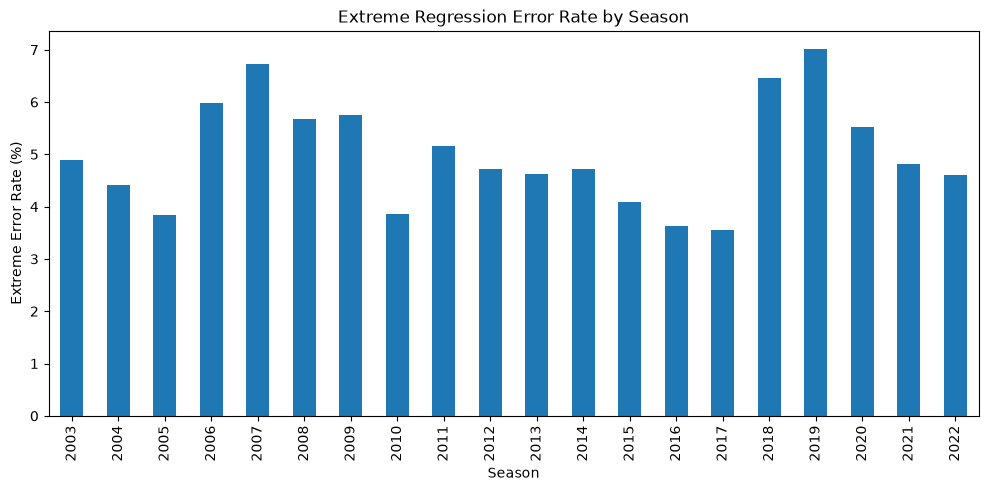

In [29]:
extreme_error_data["Is_Extreme"] = (
    extreme_error_data["Absolute_Error"] >= error_threshold
)

season_extreme_rate = (
    extreme_error_data
    .groupby("SEASON")["Is_Extreme"]
    .mean() * 100
)

plt.figure(figsize=(12, 5))

season_extreme_rate.plot(kind="bar")

plt.xlabel("Season")
plt.ylabel("Extreme Error Rate (%)")
plt.title("Extreme Regression Error Rate by Season")

plt.show()

### Interpretation

The 95th percentile of absolute error is approximately 23.8 points, identifying 1,328 observations as the most extreme 5% of regression errors.

The most severe prediction errors are associated with unusually high or unusually low home-team scoring outcomes. For example, some games contain home-team scores above 150 points, while one extreme case contains only 36 points. These outcomes are far from typical NBA scoring levels and are therefore difficult for a simple Linear Regression model to predict.

The comparison between all observations and the extreme-error group shows that the average home and away winning percentages are very similar. The number of games already played is also similar between the two groups. This suggests that extreme errors are not strongly associated with team strength or with the stage of the season.

The extreme-error group has a somewhat higher average home-team score than the full dataset, suggesting that unusually high-scoring games contribute to some of the largest prediction errors.

The seasonal error-rate analysis shows some variation across years. The highest extreme-error rate occurs in the 2019 season at approximately 7.0%, followed by 2007 and 2018. However, extreme errors are present across all seasons, and no single season completely dominates the failures.

There is no clear evidence that the largest errors are caused primarily by data quality problems. The extreme values observed are unusual but still plausible basketball outcomes.

Overall, the extreme errors appear to arise mainly from two sources:

1. **Rare or exceptional cases** – unusually high- or low-scoring games that differ substantially from typical observations.
2. **Model limitations** – Linear Regression produces relatively smooth predictions and has limited ability to represent unusual or nonlinear game behavior.

Therefore, the extreme errors appear to reflect rare game outcomes and limitations of the baseline model more than obvious data corruption.

## 1.4 Statistical Properties of Errors

The statistical properties of the regression errors are examined using the Mean Absolute Error (MAE), the standard deviation of the residuals, skewness, and kurtosis.

These measures help assess the typical error size, the variability of the residuals, possible asymmetry, and the presence of heavy tails.

In [30]:
from sklearn.metrics import mean_absolute_error
from scipy.stats import skew, kurtosis

mae = mean_absolute_error(y_reg, y_pred_reg)
residual_std = residuals.std()
residual_skewness = skew(residuals)
residual_kurtosis = kurtosis(residuals)

print("MAE:", round(mae, 2))
print("Residual standard deviation:", round(residual_std, 2))
print("Residual skewness:", round(residual_skewness, 2))
print("Residual kurtosis:", round(residual_kurtosis, 2))

MAE: 9.67
Residual standard deviation: 12.18
Residual skewness: 0.15
Residual kurtosis: 0.19


### Interpretation

The Mean Absolute Error is approximately 9.67 points, meaning that the Linear Regression model misses the actual home-team score by about 10 points on average.

The residual standard deviation is approximately 12.18 points, indicating noticeable variability around the model predictions.

The residual skewness is 0.15, which is close to zero. This suggests that the residual distribution is approximately symmetric and that there is no strong systematic tendency toward either underprediction or overprediction.

The residual kurtosis is 0.19. Because this value represents excess kurtosis, a value close to zero indicates a distribution that is relatively similar to a normal distribution in terms of tail behavior.

Therefore, there is no strong evidence of heavy tails or major systematic bias in the residual distribution. However, the extreme-error analysis in Section 1.3 shows that a small number of individual games still produce very large prediction errors.

# 2. Regression Models

Three regression models are compared using the same feature set and the same 5-fold cross-validation strategy:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

The goal is to compare models with different assumptions and levels of flexibility while keeping the evaluation procedure consistent.

In [31]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [32]:
regression_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(
        max_depth=6,
        random_state=42
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
}

### Model Settings

The Linear Regression model uses its default settings.

The Decision Tree is limited to a maximum depth of 6 to reduce excessive model complexity and overfitting.

The Random Forest uses 100 trees with a maximum depth of 10. This provides a more flexible nonlinear model while keeping computational complexity reasonable.

No extensive hyperparameter tuning is performed, because the main objective of this assignment is model comparison and error analysis rather than optimization.

In [33]:
regression_results = []

for model_name, model in regression_models.items():
    predictions = cross_val_predict(
        model,
        X_reg,
        y_reg,
        cv=cv
    )

    mse = mean_squared_error(y_reg, predictions)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_reg, predictions)
    r2 = r2_score(y_reg, predictions)

    regression_results.append({
        "Model": model_name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })

In [34]:
regression_results_df = pd.DataFrame(regression_results)

regression_results_df.round(3)

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,9.672,148.288,12.177,0.160
1,Decision Tree,9.494,143.585,11.983,0.186
2,Random Forest,9.393,140.930,11.871,0.201


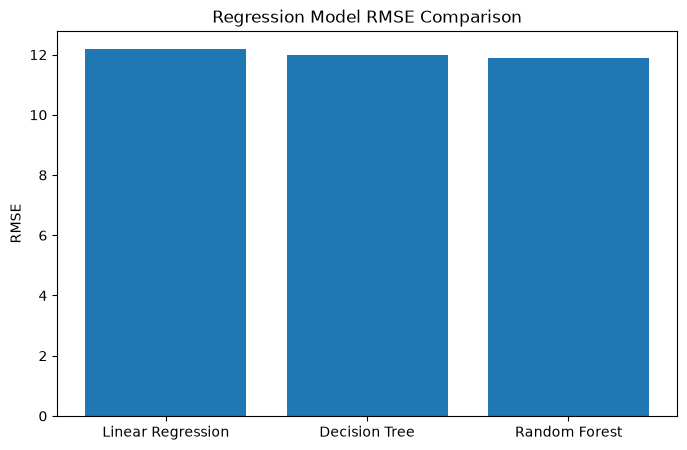

In [35]:
plt.figure(figsize=(8, 5))

plt.bar(
    regression_results_df["Model"],
    regression_results_df["RMSE"]
)

plt.ylabel("RMSE")
plt.title("Regression Model RMSE Comparison")

plt.show()

### Regression Model Comparison and Discussion

The three regression models show relatively similar performance, although the nonlinear models perform slightly better than Linear Regression.

The Linear Regression model achieves an RMSE of approximately 12.18 points and an R² of 0.16. The Decision Tree improves the RMSE to approximately 11.98 points and the R² to 0.19. The Random Forest provides the best overall performance, with an RMSE of approximately 11.87 points, an MAE of 9.39 points, and an R² of approximately 0.20.

Although the Random Forest performs best across all evaluated metrics, the improvement over the simpler models is relatively modest. This suggests that the available pre-game features contain useful predictive information, but they explain only a limited portion of the variation in home-team scoring.

#### Model Assumptions

Linear Regression assumes that the relationship between the predictors and the target can be approximated by a linear function. The residual analysis in Section 1 did not show strong systematic patterns or clear visual evidence of heteroscedasticity. However, not all Linear Regression assumptions were formally tested, and observations from repeated games involving the same teams may not be fully independent.

The slightly better performance of the tree-based models suggests that some nonlinear relationships or feature interactions may exist.

Decision Trees and Random Forests do not require a linear relationship and can represent threshold effects and interactions between variables such as team winning percentages, season, and the number of games played.

#### Bias-Variance Trade-off

Linear Regression is the simplest model and therefore has relatively low variance but higher bias when the true relationship is not fully linear.

A Decision Tree is more flexible and can reduce bias by capturing nonlinear patterns. However, individual trees can have higher variance and may be sensitive to changes in the training data.

The Random Forest reduces this variance by averaging predictions from many different trees. This provides a more stable model while retaining the ability to capture nonlinear patterns.

#### Sensitivity to Outliers and Noise

Linear Regression can be affected by extreme target values because large residuals influence the fitted model.

Decision Trees can also react strongly to unusual observations by creating splits that attempt to explain them.

Random Forest is generally more stable because individual tree errors are averaged across many trees. However, the extreme-error analysis showed that the dataset contains rare scoring outcomes that are inherently difficult to predict using the available pre-game information.

#### When Linear Models May Fail

Linear Regression may fail when relationships between team characteristics and scoring are nonlinear or when predictors interact with one another. For example, the effect of a team's winning percentage may depend on the strength of the opposing team or on the stage of the season.

Tree-based models can represent these relationships without explicitly defining interaction terms or nonlinear transformations.

#### Interpretability vs Predictive Performance

Linear Regression is the most interpretable model because its structure is simple and the effect of each feature can be examined directly.

A Decision Tree remains relatively interpretable because its predictions can be represented as a sequence of decision rules.

Random Forest is less interpretable because it combines many different trees, but it provides the best predictive performance in this comparison.

#### Preferred Model

The Random Forest is the preferred model for future regression analysis because it achieves the lowest MAE, MSE, and RMSE and the highest R².

However, its improvement over the simpler models is small. Therefore, the main limitation appears to be the amount of predictive information contained in the current feature set rather than the choice of regression algorithm alone.

#### What Was Learned from the Modeling Stage?

The modeling stage shows that additional model complexity produces only a moderate improvement in predicting NBA home-team scoring.

This suggests that pre-game winning percentages, season, and games played provide some useful information, but many factors that influence the final score are not represented in the current dataset. Improving prediction may therefore require better pre-game features rather than simply using a more complex model.

# 3. Classification Error Analysis

For the classification task, the target variable is `HOME_TEAM_WINS`:

- `1` indicates that the home team won.
- `0` indicates that the home team lost.

To avoid target leakage, only information available before the game is used as input features.

The classification analysis uses the same pre-game feature set as the regression analysis:
- Season
- Home team winning percentage
- Away team winning percentage
- Number of games already played by the home team
- Number of games already played by the away team

In [36]:
classification_features = [
    "SEASON",
    "HOME_W_PCT",
    "AWAY_W_PCT",
    "HOME_G",
    "AWAY_G"
]

X_clf = model_data[classification_features]
y_clf = model_data["HOME_TEAM_WINS"]

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold

### Classification Cross-Validation Strategy

A 5-fold Stratified K-Fold cross-validation strategy is used for classification.

Stratification preserves approximately the same class distribution in each fold, which is appropriate for the binary home-win target. Five folds also maintain consistency with the regression analysis while providing a reliable evaluation across the full dataset.

As in the regression analysis, the folds are not strictly chronological. This should be considered when interpreting the results as estimates of general model behavior rather than as a simulation of future-season forecasting.

In [38]:
classification_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logistic_model = LogisticRegression(
    max_iter=1000
)

y_proba_clf = cross_val_predict(
    logistic_model,
    X_clf,
    y_clf,
    cv=classification_cv,
    method="predict_proba"
)[:, 1]

y_pred_clf = (y_proba_clf >= 0.5).astype(int)

## 3.1 Confusion Matrix Analysis

The baseline classification threshold is set to 0.5.

Predictions generated through stratified 5-fold cross-validation are used to construct the confusion matrix.

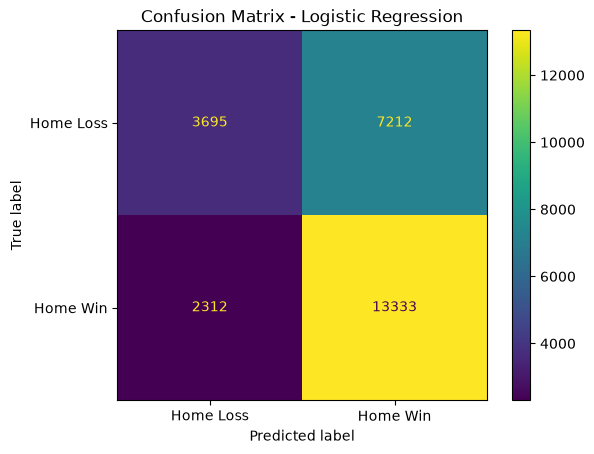

In [39]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_clf, y_pred_clf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Home Loss", "Home Win"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Interpretation

The confusion matrix shows that the Logistic Regression model predicts home-team wins much more successfully than home-team losses.

The model correctly identifies 13,333 home wins and 3,695 home losses. However, it produces 7,212 False Positives, where a home win is predicted but the home team actually loses. In comparison, there are only 2,312 False Negatives, where a home loss is predicted but the home team actually wins.

The dominant classification error is therefore the False Positive. The model appears to have a tendency to predict a home-team win too frequently.

In this basketball prediction context, neither error type has an inherently higher real-world cost because the assignment does not define a specific decision or financial consequence. However, False Positives are the more important failure mode for this model because they occur much more frequently. If the model were used to identify likely home winners, these errors would reduce the reliability of positive predictions.

The confusion matrix also suggests a systematic failure region: actual home losses are substantially harder for the model to recognize than actual home wins. This may result from the limited pre-game feature set and from the general home-team advantage present in the data.

More detailed feature-based regions of misclassification will be examined in Section 3.3.

## 3.2 Probability-Based Analysis

Predicted probabilities are compared between correct and incorrect classifications.

The objective is to determine whether the model makes errors mainly when it is uncertain, or whether some incorrect predictions are made with high confidence.

For a consistent comparison, probability is expressed as the confidence assigned to the predicted class. For a predicted home win, this is the predicted home-win probability. For a predicted home loss, it is one minus the predicted home-win probability.

For this analysis, a high-confidence prediction is operationally defined as a predicted-class probability of at least 0.80.

In [40]:
probability_analysis = pd.DataFrame({
    "True_Label": y_clf.to_numpy(),
    "Predicted_Label": y_pred_clf,
    "Home_Win_Probability": y_proba_clf
})

probability_analysis["Correct"] = (
    probability_analysis["True_Label"]
    == probability_analysis["Predicted_Label"]
)

In [41]:
probability_analysis["Prediction_Confidence"] = np.where(
    probability_analysis["Predicted_Label"] == 1,
    probability_analysis["Home_Win_Probability"],
    1 - probability_analysis["Home_Win_Probability"]
)

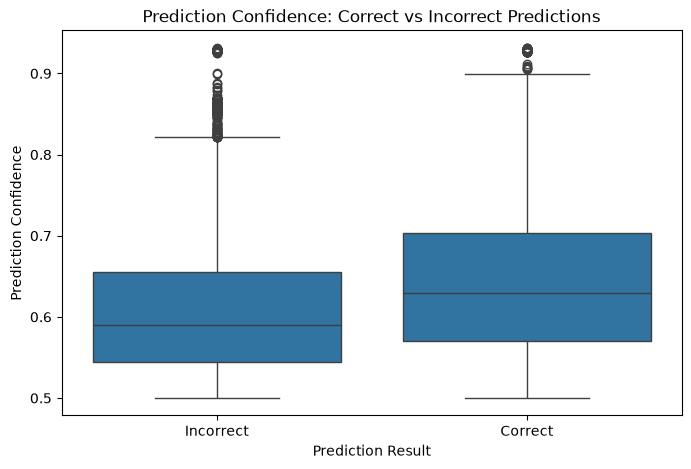

In [42]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=probability_analysis,
    x="Correct",
    y="Prediction_Confidence"
)

plt.xticks(
    [0, 1],
    ["Incorrect", "Correct"]
)

plt.xlabel("Prediction Result")
plt.ylabel("Prediction Confidence")
plt.title("Prediction Confidence: Correct vs Incorrect Predictions")

plt.show()

In [43]:
high_confidence_errors = probability_analysis[
    (~probability_analysis["Correct"])
    & (probability_analysis["Prediction_Confidence"] >= 0.80)
]

print(
    "Number of high-confidence errors:",
    len(high_confidence_errors)
)

Number of high-confidence errors: 391


### Interpretation

Correct predictions tend to receive higher confidence than incorrect predictions.

The average prediction confidence is approximately 0.64 for correct predictions and approximately 0.61 for incorrect predictions. The boxplot also shows considerable overlap between the two groups, indicating that confidence alone does not clearly separate correct from incorrect classifications.

Most incorrect predictions occur at moderate confidence levels, but the model also produces 391 high-confidence errors with a confidence of at least 0.80.

These high-confidence errors include both cases where the model strongly predicts a home win but the home team loses, and cases where the model strongly predicts a home loss but the home team wins.

This is an important limitation because it shows that the model can occasionally be confidently wrong rather than simply making errors near the 0.5 decision threshold.

Overall, prediction confidence provides some information about reliability, but the overlap between correct and incorrect predictions suggests that the model's probabilities should not be interpreted as perfectly calibrated measures of certainty.

## 3.3 Error as a Function of Features

Feature distributions are compared between correct and incorrect classification predictions.

The analysis focuses on home-team winning percentage, away-team winning percentage, and season in order to identify regions where the classification model is more likely to fail.

In [44]:
classification_error_analysis = X_clf.copy()

classification_error_analysis["Correct"] = (
    y_clf.to_numpy() == y_pred_clf
)

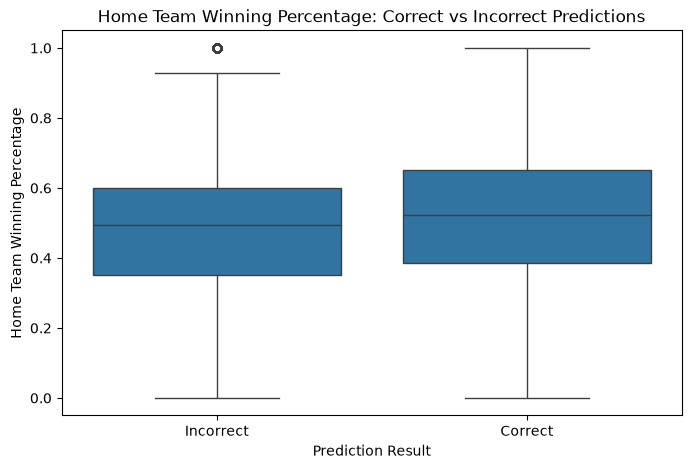

In [45]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=classification_error_analysis,
    x="Correct",
    y="HOME_W_PCT"
)

plt.xticks(
    [0, 1],
    ["Incorrect", "Correct"]
)

plt.xlabel("Prediction Result")
plt.ylabel("Home Team Winning Percentage")
plt.title("Home Team Winning Percentage: Correct vs Incorrect Predictions")

plt.show()

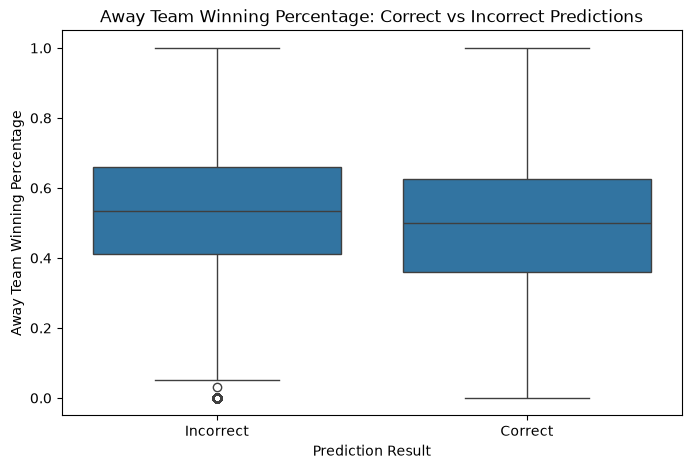

In [46]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=classification_error_analysis,
    x="Correct",
    y="AWAY_W_PCT"
)

plt.xticks(
    [0, 1],
    ["Incorrect", "Correct"]
)

plt.xlabel("Prediction Result")
plt.ylabel("Away Team Winning Percentage")
plt.title("Away Team Winning Percentage: Correct vs Incorrect Predictions")

plt.show()

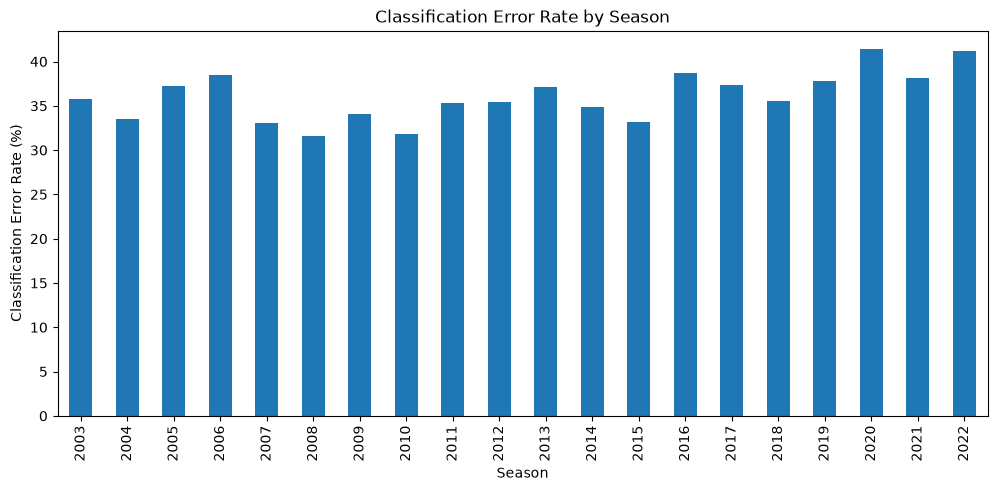

In [47]:
season_classification_error = (
    classification_error_analysis
    .groupby("SEASON")["Correct"]
    .apply(lambda values: 100 * (1 - values.mean()))
)

plt.figure(figsize=(12, 5))

season_classification_error.plot(kind="bar")

plt.xlabel("Season")
plt.ylabel("Classification Error Rate (%)")
plt.title("Classification Error Rate by Season")

plt.show()

### Interpretation

The feature distributions show meaningful differences between correct and incorrect predictions.

Incorrect predictions tend to occur when the home team has a lower winning percentage. The average home-team winning percentage is approximately 0.47 for incorrect predictions, compared with approximately 0.51 for correct predictions.

At the same time, incorrect predictions tend to occur when the away team has a higher winning percentage. The average away-team winning percentage is approximately 0.53 for incorrect predictions, compared with approximately 0.49 for correct predictions.

This suggests that the model is more likely to fail in games where the home team is relatively weaker and the away team is relatively stronger. This is consistent with the confusion-matrix result, where False Positives were the dominant error type: the model often predicts a home win when the home team actually loses.

The seasonal analysis also shows variation in classification performance. The highest observed error rates occur in 2020 and 2022, both above 41%. However, the 2022 season is only partially represented in the dataset, so its error rate should be interpreted with caution.

Overall, the classification model does not fail uniformly across the feature space. Its errors are more concentrated in games where the pre-game strength indicators favor the away team and in some specific seasons.

## 3.4 Threshold Sensitivity Analysis

Classification performance depends on the probability threshold used to convert predicted probabilities into class labels.

Thresholds from 0.1 to 0.9 are evaluated using Precision, Recall, F1-score, and Matthews Correlation Coefficient (MCC).

ROC-AUC is also evaluated using the predicted probabilities, independently of a single classification threshold.

In [48]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    roc_curve,
    fbeta_score
)

In [49]:
thresholds = np.arange(0.1, 1.0, 0.1)

threshold_results = []

for threshold in thresholds:
    predictions = (y_proba_clf >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_clf, predictions, zero_division=0),
        "Recall": recall_score(y_clf, predictions, zero_division=0),
        "F1": f1_score(y_clf, predictions, zero_division=0),
        "MCC": matthews_corrcoef(y_clf, predictions)
    })

threshold_results_df = pd.DataFrame(threshold_results)

threshold_results_df.round(3)

,Threshold,Precision,Recall,F1,MCC
0,0.1,0.589,1.000,0.742,0.000
1,0.2,0.590,0.991,0.740,0.022
2,0.3,0.594,0.985,0.741,0.061
3,0.4,0.609,0.953,0.743,0.137
4,0.5,0.649,0.852,0.737,0.225
5,0.6,0.721,0.590,0.649,0.258
6,0.7,0.786,0.260,0.390,0.197
7,0.8,0.766,0.054,0.100,0.074
8,0.9,0.643,0.008,0.015,0.009


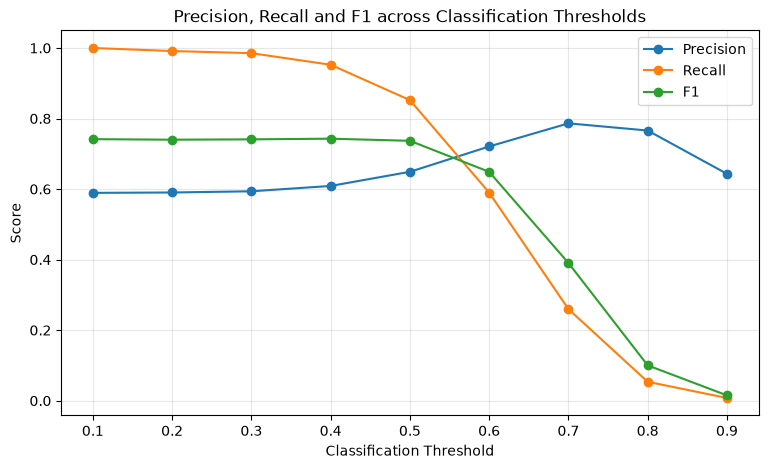

In [50]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["F1"],
    marker="o",
    label="F1"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 across Classification Thresholds")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

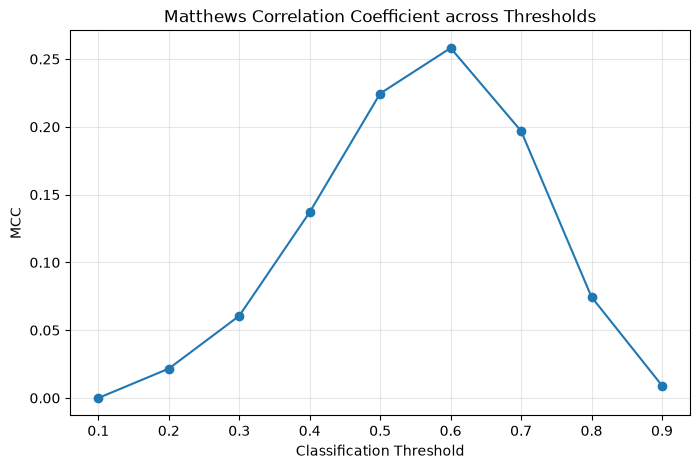

In [51]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results_df["Threshold"],
    threshold_results_df["MCC"],
    marker="o"
)

plt.xlabel("Classification Threshold")
plt.ylabel("MCC")
plt.title("Matthews Correlation Coefficient across Thresholds")
plt.grid(alpha=0.3)

plt.show()

In [52]:
auc_score = roc_auc_score(y_clf, y_proba_clf)

fpr, tpr, _ = roc_curve(y_clf, y_proba_clf)

print("ROC-AUC:", round(auc_score, 3))

ROC-AUC: 0.675


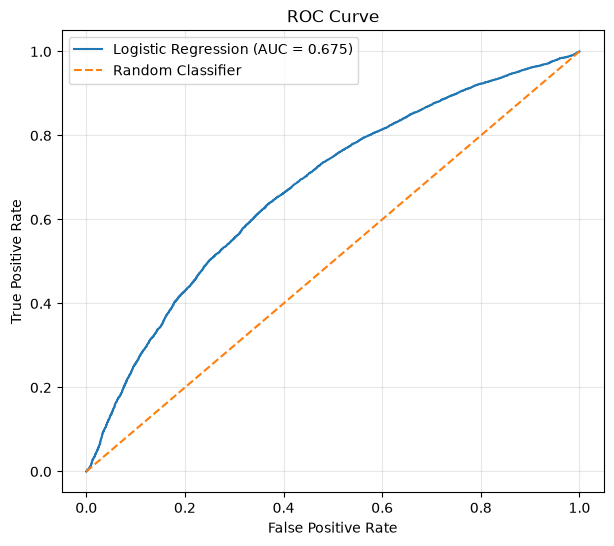

In [53]:
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### F-beta Analysis

The F-beta score changes the relative importance of Precision and Recall.

Values below 1 emphasize Precision, while values above 1 emphasize Recall. The analysis below uses the baseline classification threshold of 0.5.

In [54]:
beta_values = np.arange(0.1, 3.1, 0.1)

baseline_predictions = (y_proba_clf >= 0.5).astype(int)

f_beta_scores = [
    fbeta_score(
        y_clf,
        baseline_predictions,
        beta=beta
    )
    for beta in beta_values
]

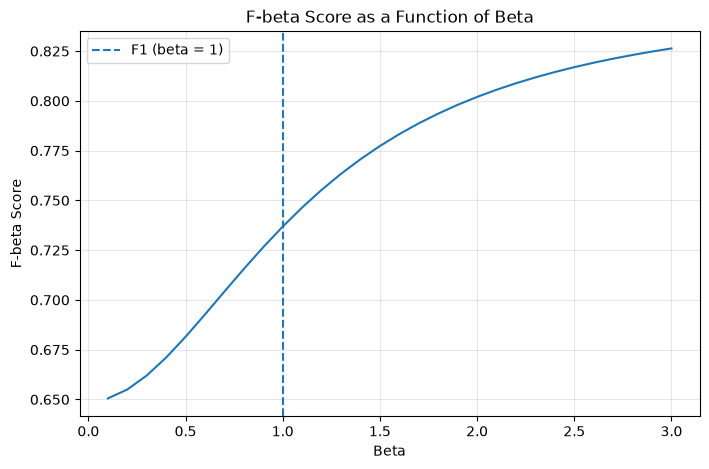

In [55]:
plt.figure(figsize=(8, 5))

plt.plot(
    beta_values,
    f_beta_scores
)

plt.axvline(
    1,
    linestyle="--",
    label="F1 (beta = 1)"
)

plt.xlabel("Beta")
plt.ylabel("F-beta Score")
plt.title("F-beta Score as a Function of Beta")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### Interpretation

The classification threshold strongly affects the balance between Precision and Recall.

At low thresholds, the model predicts a home win for almost every game. As a result, Recall is extremely high, reaching nearly 1.0, while Precision remains relatively low. This operating region produces many False Positives.

As the threshold increases, Precision improves because the model becomes more selective when predicting a home win. However, Recall decreases substantially because many actual home wins are no longer classified as positive.

The highest F1-score occurs at a threshold of approximately 0.4, where Recall remains very high while Precision improves slightly. In contrast, the highest MCC occurs at a threshold of approximately 0.6. This threshold provides a better overall balance between correct positive and negative classifications.

Thresholds above 0.7 are unstable for this model. Recall falls sharply, meaning that the model misses most actual home wins. Thresholds below 0.3 are also not very informative because the model predicts almost all observations as home wins.

Therefore, the most useful operating region is approximately between 0.4 and 0.6. The exact threshold depends on whether Recall or balanced classification performance is considered more important.

The ROC-AUC score is approximately 0.675. This indicates that the model has some ability to distinguish between home wins and home losses, but the separation is only moderate.

The F-beta analysis shows that the score increases as beta increases. This happens because larger beta values place more weight on Recall, which is relatively strong for this classifier at the baseline threshold. This confirms that the model is better at identifying home wins than at avoiding False Positives.

Overall, threshold selection has a major effect on the model's error behavior. A threshold of 0.5 is reasonable as a baseline, but thresholds around 0.4 to 0.6 provide different trade-offs depending on the desired balance between Precision, Recall, and overall classification quality.

### Classification Model Comparison

To provide a broader comparison of classification approaches, three models are evaluated using the same feature set and the same 5-fold stratified cross-validation strategy:

1. Logistic Regression
2. Decision Tree Classifier
3. Random Forest Classifier

The detailed error analysis in Sections 3.1–3.4 focuses on Logistic Regression as the baseline model, while this comparison examines whether more flexible nonlinear models improve overall classification performance.

In [56]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [57]:
classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=6,
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        random_state=42,
        n_jobs=-1
    )
}

The Decision Tree is limited to a maximum depth of 6 to reduce overfitting. The Random Forest uses 100 trees with a maximum depth of 10. No extensive hyperparameter tuning is performed because the main objective is model comparison and error analysis.

In [58]:
classification_results = []

for model_name, model in classification_models.items():
    probabilities = cross_val_predict(
        model,
        X_clf,
        y_clf,
        cv=classification_cv,
        method="predict_proba"
    )[:, 1]

    predictions = (probabilities >= 0.5).astype(int)

    classification_results.append({
        "Model": model_name,
        "Precision": precision_score(y_clf, predictions, zero_division=0),
        "Recall": recall_score(y_clf, predictions, zero_division=0),
        "F1": f1_score(y_clf, predictions, zero_division=0),
        "MCC": matthews_corrcoef(y_clf, predictions),
        "ROC_AUC": roc_auc_score(y_clf, probabilities)
    })

classification_results_df = pd.DataFrame(classification_results)

classification_results_df.round(3)

,Model,Precision,Recall,F1,MCC,ROC_AUC
0,Logistic Regression,0.649,0.852,0.737,0.225,0.675
1,Decision Tree,0.668,0.776,0.718,0.235,0.673
2,Random Forest,0.670,0.791,0.725,0.248,0.681


## 3.5 Discussion

The classification model comparison shows that no single model is best across all evaluation metrics.

Logistic Regression achieves the highest Recall, approximately 0.85, and the highest F1-score, approximately 0.74. This means that it is particularly effective at identifying actual home-team wins, although it also produces a relatively large number of False Positives.

The Decision Tree provides slightly higher Precision than Logistic Regression, but lower Recall and F1-score. Its ROC-AUC is also slightly lower, suggesting that the additional nonlinear flexibility of a single tree does not provide a clear overall advantage.

The Random Forest achieves the highest MCC, approximately 0.25, and the highest ROC-AUC, approximately 0.68. These results suggest that it provides the best overall balance between the two classes and slightly better discrimination between home wins and home losses.

However, the differences between the three models are modest. This indicates that the main limitation is likely not the choice of classification algorithm alone, but also the limited amount of predictive information contained in the current pre-game feature set.

The detailed error analysis of Logistic Regression reveals several important failure patterns. False Positives are the dominant error type, meaning that the model frequently predicts a home-team win when the home team actually loses.

The probability-based analysis shows that correct predictions tend to receive slightly higher confidence than incorrect predictions. However, the difference is relatively small, and 391 errors were made with confidence levels of at least 0.80. This demonstrates that the model can occasionally be confidently wrong.

The feature-based analysis shows that classification errors are more common when the home team has a lower winning percentage and the away team has a higher winning percentage. This suggests that games in which the away team is relatively stronger form an important failure region.

Classification performance also varies across seasons. The highest observed error rates occur in 2020 and 2022, although the 2022 season is only partially represented in the dataset and should therefore be interpreted with caution.

The threshold analysis shows that model behavior changes substantially depending on the classification threshold. Low thresholds produce very high Recall but also many False Positives, while higher thresholds improve Precision but sharply reduce Recall. The best F1-score occurs around a threshold of 0.4, while MCC is highest around 0.6.

Overall, Logistic Regression is the strongest choice when Recall and F1-score are prioritized, while Random Forest is preferable when balanced classification performance and class discrimination are more important.

The results suggest that future improvements should focus primarily on richer pre-game features, such as recent team form, rest days, home and away records, injuries, and player availability, rather than relying only on increased model complexity.

# 4. Final Reflection

### 1. Where does the model fail most?

The regression model fails most on rare games with unusually high or unusually low home-team scoring. These extreme observations produce much larger residuals than typical games.

The classification model fails most often when the home team is relatively weaker and the away team is relatively stronger. This is also reflected in the large number of False Positives, where the model predicts a home-team win but the home team actually loses.

### 2. Are the failures due to data, model, or formulation?

The failures appear to result from a combination of model limitations and problem formulation rather than obvious data-quality problems.

The dataset contains valid but unusual game outcomes that are difficult to predict. The models also use a deliberately simple set of pre-game features, which limits the amount of information available for prediction.

Linear Regression has limited ability to capture nonlinear relationships and rare game behavior, while Logistic Regression provides only moderate separation between home wins and home losses.

### 3. What improvements would you propose?

The most important improvement would be to add richer pre-game features.

Possible improvements include:
- Recent team performance
- Rest days between games
- Home and away records
- Recent scoring averages
- Opponent-specific performance
- Player availability or injury information

For regression, nonlinear ensemble models could also be explored further.

For classification, the comparison already showed that Random Forest provides slightly better balanced performance than Logistic Regression, although the differences are modest. Future work could examine boosting methods or perform limited hyperparameter tuning to determine whether additional model complexity provides meaningful improvement.

Threshold selection should also depend on the practical importance of False Positives and False Negatives.

### 4. What insights did you gain from the analysis?

The analysis showed that model performance cannot be understood from a single evaluation metric.

Residual analysis revealed where regression predictions become unreliable, while the classification analysis showed how error type, probability confidence, feature values, and decision thresholds all affect model behavior.

A more complex model did not dramatically improve regression performance, suggesting that better features may be more important than additional model complexity.

The classification analysis also demonstrated that a model can make high-confidence errors and that changing the classification threshold can substantially change the balance between Precision and Recall.

Overall, the most important insight is that understanding where and why a model fails is as important as measuring its average predictive performance.